# 02 -- Feature Engineering
## VelibMMM -- Modele bayesien de disponibilite des stations

**Objectif :** construire les features qui capturent la dynamique de disponibilite
des stations Velib pour predire `fill_rate(t+30min)`.

**Analogies MMM (RobynMMM → VelibMMM) :**

| RobynMMM | VelibMMM |
|---|---|
| Depenses media (spend) | Drainage de velos (delta fill_rate negatif) |
| Adstock (memoire pub) | EMA drainage cumule |
| Saturation (Hill) | Effet sigmoide station pleine/vide |
| Canaux media | Facteurs : heure, meteo, voisinage, rush |
| Revenue(t) | fill_rate(t+30min) |

---
### Plan
1. Chargement du dataset nettoye
2. Construction de la target (fill_rate a t+30min)
3. Adstock drainage (EMA des sorties de velos)
4. Features temporelles (sin/cos periodiques)
5. Features de voisinage (stations proches)
6. Assemblage du dataset final
7. Correlations et validation
8. Export

## 0. Imports & chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.spatial import cKDTree
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

ROOT     = Path('..').resolve()
PROC_DIR = ROOT / 'data' / 'processed'
FIG_DIR  = ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Chargement
df = pd.read_parquet(PROC_DIR / 'velib_clean.parquet')
df['ts_utc'] = pd.to_datetime(df['ts_utc'], utc=True)
df = df.sort_values(['station_id', 'ts_utc']).reset_index(drop=True)

station_stats = pd.read_parquet(PROC_DIR / 'station_stats.parquet')

print(f'[OK] Dataset : {df.shape}')
print(f'Stations     : {df["station_id"].nunique()}')
print(f'Snapshots    : {df["ts_utc"].nunique()}')
print(f'Periode      : {df["ts_utc"].min()} --> {df["ts_utc"].max()}')
print(f'Colonnes     : {df.columns.tolist()}')

[OK] Dataset : (218151, 18)
Stations     : 1485
Snapshots    : 147
Periode      : 2025-11-10 11:34:10.985346+00:00 --> 2025-11-13 11:30:30.954158+00:00
Colonnes     : ['ts_utc', 'station_id', 'fill_rate', 'num_bikes_available', 'num_docks_available', 'available_mechanical', 'available_ebike', 'capacity', 'lat', 'lon', 'name', 'is_installed', 'hour', 'day_of_week', 'date', 'is_weekend', 'week', 'is_rush']


## 1. Construction de la target : fill_rate(t+30min)

Pour chaque station et chaque snapshot t, on cherche le fill_rate
au snapshot le plus proche de t+30min.

C'est la variable qu'on veut **predire** -- l'equivalent du revenue dans RobynMMM.

**Methode :** pour chaque (station, t), on cherche le snapshot suivant
dans la fenetre [t+15min, t+45min] et on prend le fill_rate correspondant.

In [4]:
print('Construction de la target fill_rate(t+30min)...')

timestamps = sorted(df['ts_utc'].unique())
print(f'Nombre de timestamps : {len(timestamps)}')

if len(timestamps) > 1:
    deltas = [(timestamps[i+1] - timestamps[i]).total_seconds()/60
              for i in range(min(10, len(timestamps)-1))]
    median_interval = np.median(deltas)
    print(f'Intervalle median entre snapshots : {median_interval:.0f} minutes')
else:
    median_interval = 60

HORIZON_MIN = 30
ts_array = np.array([t.timestamp() for t in timestamps])

# ── FIX : on retourne directement le timestamp pandas existant ──
def find_future_ts(t, horizon_min=30, tolerance_min=20):
    target_sec = t.timestamp() + horizon_min * 60
    tol_sec    = tolerance_min * 60
    mask = (ts_array >= target_sec - tol_sec) & (ts_array <= target_sec + tol_sec)
    candidates_sec = ts_array[mask]
    if len(candidates_sec) == 0:
        return None
    best_sec = candidates_sec[np.argmin(np.abs(candidates_sec - target_sec))]
    # On retourne le timestamp pandas original, pas une reconstruction
    return timestamps[np.where(ts_array == best_sec)[0][0]]

ts_to_future = {}
for t in timestamps:
    fut = find_future_ts(t, HORIZON_MIN)
    if fut is not None:
        ts_to_future[t] = fut

n_mapped = len(ts_to_future)
print(f'Timestamps avec futur trouve : {n_mapped} / {len(timestamps)} ({n_mapped/len(timestamps)*100:.0f}%)')

# Construction du dataset avec target
records = []
for ts_curr, ts_fut in ts_to_future.items():
    curr = df[df['ts_utc'] == ts_curr][['station_id', 'fill_rate']].set_index('station_id')
    fut  = df[df['ts_utc'] == ts_fut][['station_id', 'fill_rate']].set_index('station_id')
    fut  = fut.rename(columns={'fill_rate': 'fill_rate_t30'})
    merged = curr.join(fut, how='inner')
    merged['ts_utc'] = ts_curr
    records.append(merged.reset_index())

df_target = pd.concat(records, ignore_index=True)
df_target['ts_utc'] = pd.to_datetime(df_target['ts_utc'], utc=True)

print(f'\n[OK] Dataset avec target : {df_target.shape}')
print(f'fill_rate_t30 stats :')
print(df_target['fill_rate_t30'].describe().round(3))
df_target.head(3)

Construction de la target fill_rate(t+30min)...
Nombre de timestamps : 147
Intervalle median entre snapshots : 13 minutes
Timestamps avec futur trouve : 113 / 147 (77%)

[OK] Dataset avec target : (167693, 4)
fill_rate_t30 stats :
count    167693.000
mean          0.387
std           0.284
min           0.000
25%           0.143
50%           0.321
75%           0.600
max           1.000
Name: fill_rate_t30, dtype: float64


,station_id,fill_rate,fill_rate_t30,ts_utc
0,6245,0.962963,0.962963,2025-11-10 12:47:10.029131+00:00
1,6293,0.785714,0.714286,2025-11-10 12:47:10.029131+00:00
2,6294,0.956522,0.956522,2025-11-10 12:47:10.029131+00:00


Correlation fill_rate(t) vs fill_rate(t+30) : r=0.965
(attendu : eleve car les stations changent lentement -- bon signe)


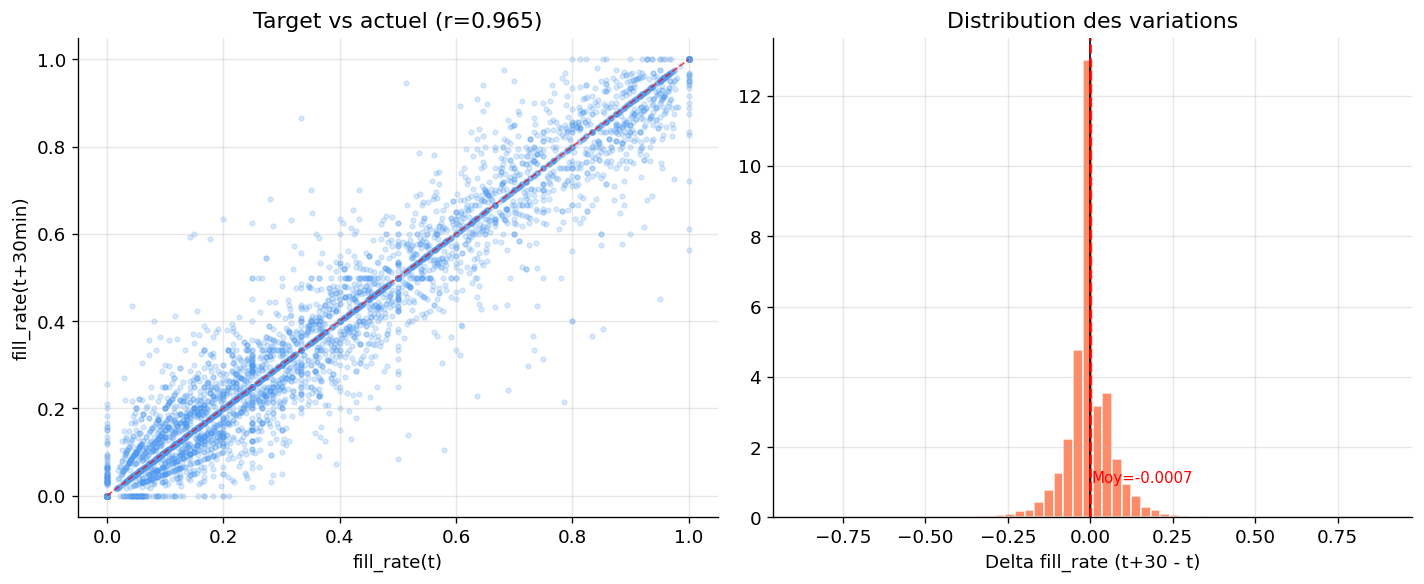

[OK] Figure sauvegardee


In [5]:
# Validation : correlation fill_rate(t) vs fill_rate(t+30)
r = df_target['fill_rate'].corr(df_target['fill_rate_t30'])
print(f'Correlation fill_rate(t) vs fill_rate(t+30) : r={r:.3f}')
print(f'(attendu : eleve car les stations changent lentement -- bon signe)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
sample = df_target.sample(min(5000, len(df_target)), random_state=42)
ax.scatter(sample['fill_rate'], sample['fill_rate_t30'],
           alpha=0.2, s=8, color='#4E9AF1')
ax.plot([0,1],[0,1], color='red', linewidth=1, linestyle='--', alpha=0.7)
ax.set_xlabel('fill_rate(t)')
ax.set_ylabel('fill_rate(t+30min)')
ax.set_title(f'Target vs actuel (r={r:.3f})')

ax2 = axes[1]
delta = df_target['fill_rate_t30'] - df_target['fill_rate']
ax2.hist(delta, bins=60, color='#FF7043', alpha=0.8, edgecolor='white', density=True)
ax2.axvline(x=0, color='black', linewidth=1)
ax2.axvline(x=delta.mean(), color='red', linestyle='--')
delta_mean = delta.mean()
ax2.annotate(f'Moy={delta_mean:.4f}', xy=(delta_mean+0.005, 1),
             fontsize=9, color='red')
ax2.set_xlabel('Delta fill_rate (t+30 - t)')
ax2.set_title('Distribution des variations')

plt.tight_layout()
plt.savefig(str(FIG_DIR / '02_target_validation.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')

## 2. Adstock drainage -- EMA des sorties de velos

**Concept :** quand une station perd des velos, cet effet persiste
(les velos partis ne reviennent pas instantanement).
On capture cela avec une EMA (Exponential Moving Average) des variations negatives.

**Analogie RobynMMM :**
```
# RobynMMM
adstock(t) = spend(t) + lambda * adstock(t-1)

# VelibMMM
drainage(t) = max(0, fill_rate(t-1) - fill_rate(t))  # sorties de velos
adstock_drain(t) = drainage(t) + alpha * adstock_drain(t-1)
```

**Parametres :**
- `alpha = 0.4` : decay du drainage (meme logique que lambda en MMM)
- Demi-vie = log(0.5)/log(0.4) ≈ 1.1 snapshots (~1h)

In [6]:
def compute_adstock_drainage(group, alpha=0.4):
    fr = group['fill_rate'].values
    n  = len(fr)

    # Drainage = variation negative (sorties de velos)
    drainage = np.zeros(n)
    for i in range(1, n):
        drainage[i] = max(0.0, fr[i-1] - fr[i])

    # Adstock = EMA du drainage (memoire des sorties)
    adstock = np.zeros(n)
    adstock[0] = drainage[0]
    for i in range(1, n):
        adstock[i] = drainage[i] + alpha * adstock[i-1]

    # Surplus = variation positive (arrivees de velos)
    surplus = np.zeros(n)
    for i in range(1, n):
        surplus[i] = max(0.0, fr[i] - fr[i-1])

    group = group.copy()
    group['drainage']      = drainage
    group['adstock_drain'] = adstock
    group['surplus']       = surplus
    return group

ALPHA_ADSTOCK = 0.4

print('Calcul adstock drainage par station...')
df_adstock = (
    df
    .sort_values(['station_id', 'ts_utc'])
    .groupby('station_id', group_keys=False)
    .apply(lambda g: compute_adstock_drainage(g, ALPHA_ADSTOCK))
    .reset_index(drop=True)
)

hl = np.log(0.5) / np.log(ALPHA_ADSTOCK)
print(f'[OK] Adstock calcule | alpha={ALPHA_ADSTOCK} | demi-vie={hl:.1f} snapshots')
print(f'\nStats drainage :')
print(df_adstock['drainage'].describe().round(4))
print(f'\nStats adstock_drain :')
print(df_adstock['adstock_drain'].describe().round(4))

Calcul adstock drainage par station...
[OK] Adstock calcule | alpha=0.4 | demi-vie=0.8 snapshots

Stats drainage :
count    218151.0000
mean          0.0194
std           0.0469
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0233
max           0.9200
Name: drainage, dtype: float64

Stats adstock_drain :
count    218151.0000
mean          0.0321
std           0.0549
min           0.0000
25%           0.0007
50%           0.0112
75%           0.0410
max           0.9221
Name: adstock_drain, dtype: float64


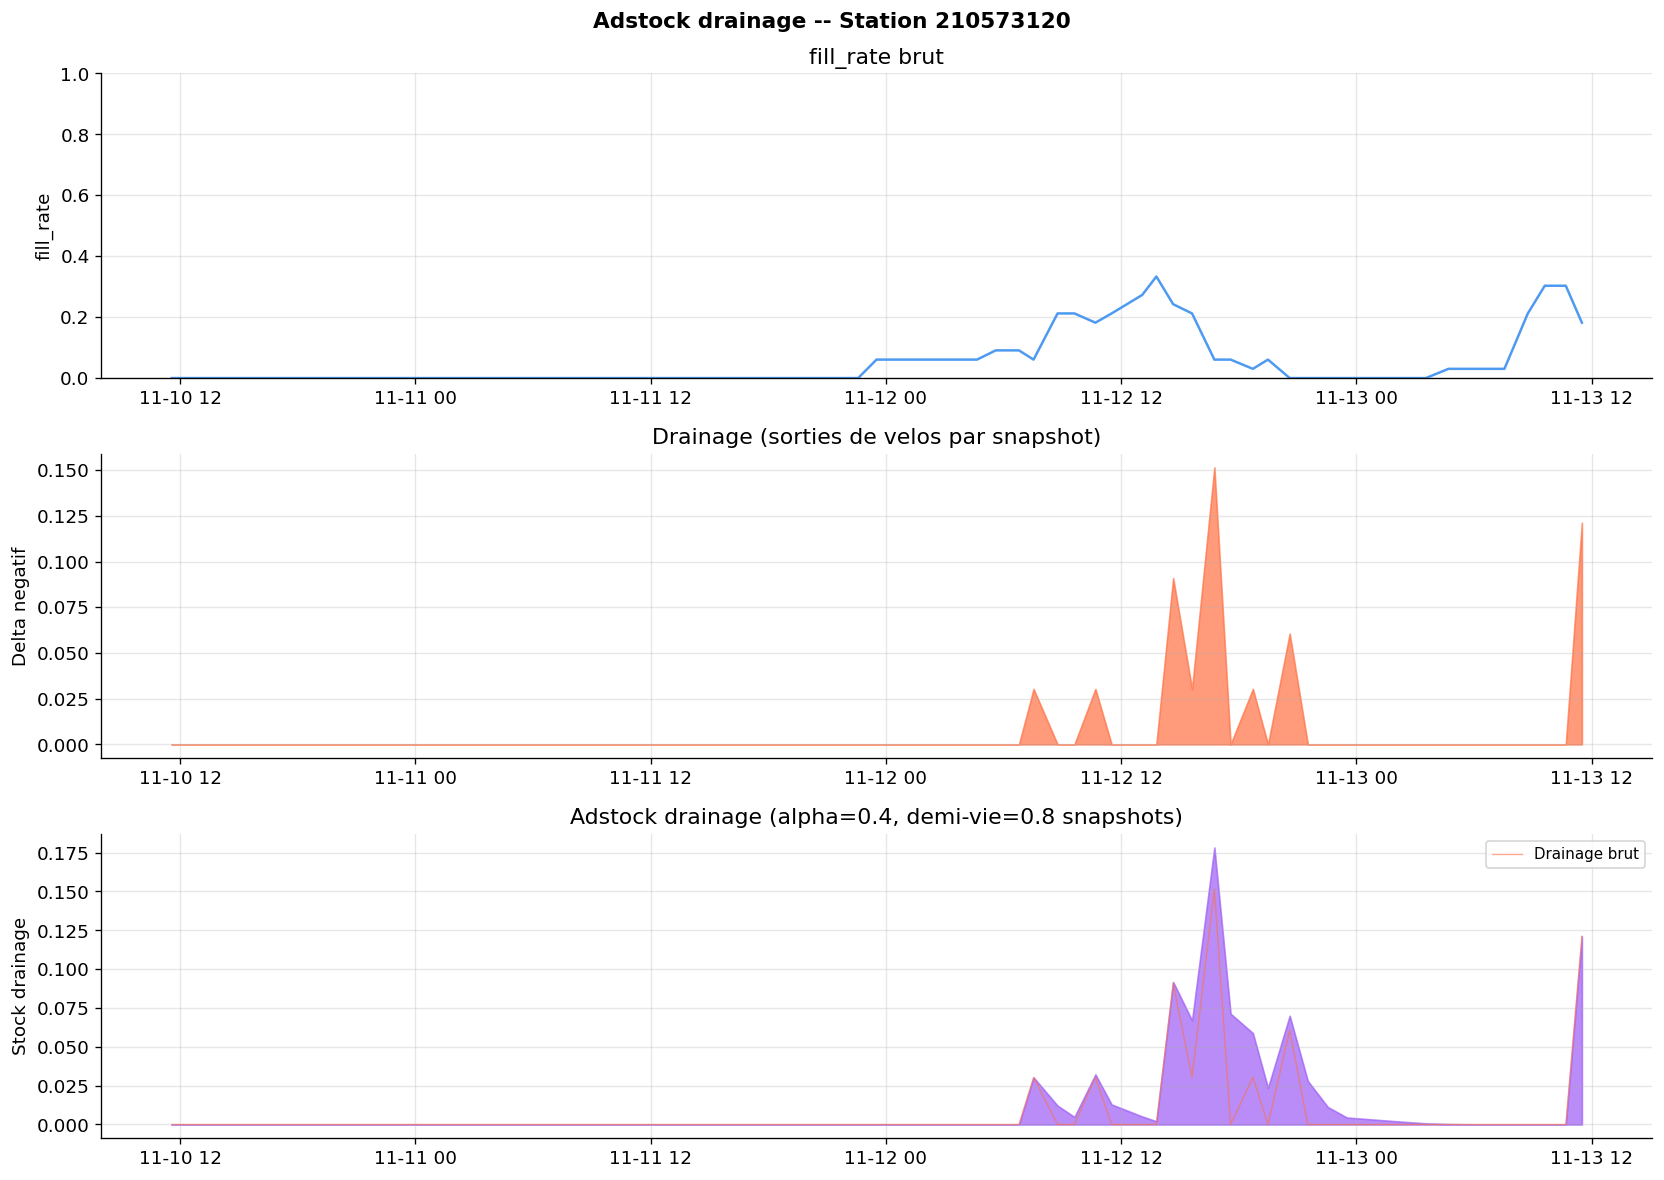

[OK] Figure sauvegardee


In [7]:
# Visualisation sur une station representative
# Choisir une station avec beaucoup de variabilite
station_ex = station_stats.nlargest(3, 'cv')['station_id'].iloc[1]
df_ex = df_adstock[df_adstock['station_id'] == station_ex].sort_values('ts_utc')

if len(df_ex) == 0:
    station_ex = df_adstock['station_id'].iloc[0]
    df_ex = df_adstock[df_adstock['station_id'] == station_ex].sort_values('ts_utc')

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle(f'Adstock drainage -- Station {station_ex}', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(df_ex['ts_utc'], df_ex['fill_rate'], color='#4E9AF1', linewidth=1.5)
ax.set_title('fill_rate brut')
ax.set_ylabel('fill_rate')
ax.set_ylim(0, 1)

ax2 = axes[1]
ax2.fill_between(df_ex['ts_utc'], df_ex['drainage'], alpha=0.7, color='#FF7043')
ax2.set_title('Drainage (sorties de velos par snapshot)')
ax2.set_ylabel('Delta negatif')

ax3 = axes[2]
ax3.fill_between(df_ex['ts_utc'], df_ex['adstock_drain'], alpha=0.7, color='#9C5CF5')
ax3.plot(df_ex['ts_utc'], df_ex['drainage'], color='#FF7043',
         linewidth=0.8, alpha=0.6, label='Drainage brut')
ax3.set_title(f'Adstock drainage (alpha={ALPHA_ADSTOCK}, demi-vie={hl:.1f} snapshots)')
ax3.set_ylabel('Stock drainage')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(FIG_DIR / '02_adstock_drainage.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')

## 3. Features temporelles

Les features temporelles capturent les patterns cycliques de disponibilite.
On utilise des encodages **sin/cos** pour preserver la continuite cyclique
(minuit est proche de 23h, lundi est proche de dimanche).

```
hour_sin = sin(2*pi*hour/24)
hour_cos = cos(2*pi*hour/24)
dow_sin  = sin(2*pi*day_of_week/7)
dow_cos  = cos(2*pi*day_of_week/7)
```

In [8]:
def add_temporal_features(df):
    df = df.copy()

    # Encodage cyclique heure
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Encodage cyclique jour de semaine
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # Indicateurs binaires
    df['is_rush']    = df['hour'].isin([7,8,9,17,18,19]).astype(int)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_night']   = df['hour'].isin([22,23,0,1,2,3,4,5]).astype(int)

    # Minute normalisee dans la journee (0 a 1)
    df['time_of_day'] = (df['hour'] * 60) / (24 * 60)

    return df

df_features = add_temporal_features(df_adstock)

feat_temp = ['hour_sin','hour_cos','dow_sin','dow_cos','is_rush','is_weekend','is_night','time_of_day']
print('[OK] Features temporelles ajoutees :')
for f in feat_temp:
    print(f'  {f:<20} min={df_features[f].min():.3f}  max={df_features[f].max():.3f}  mean={df_features[f].mean():.3f}')

[OK] Features temporelles ajoutees :
  hour_sin             min=-1.000  max=1.000  mean=-0.154
  hour_cos             min=-1.000  max=1.000  mean=-0.122
  dow_sin              min=0.000  max=0.975  mean=0.538
  dow_cos              min=-0.901  max=1.000  mean=0.508
  is_rush              min=0.000  max=1.000  mean=0.306
  is_weekend           min=0.000  max=0.000  mean=0.000
  is_night             min=0.000  max=1.000  mean=0.224
  time_of_day          min=0.000  max=0.958  mean=0.563


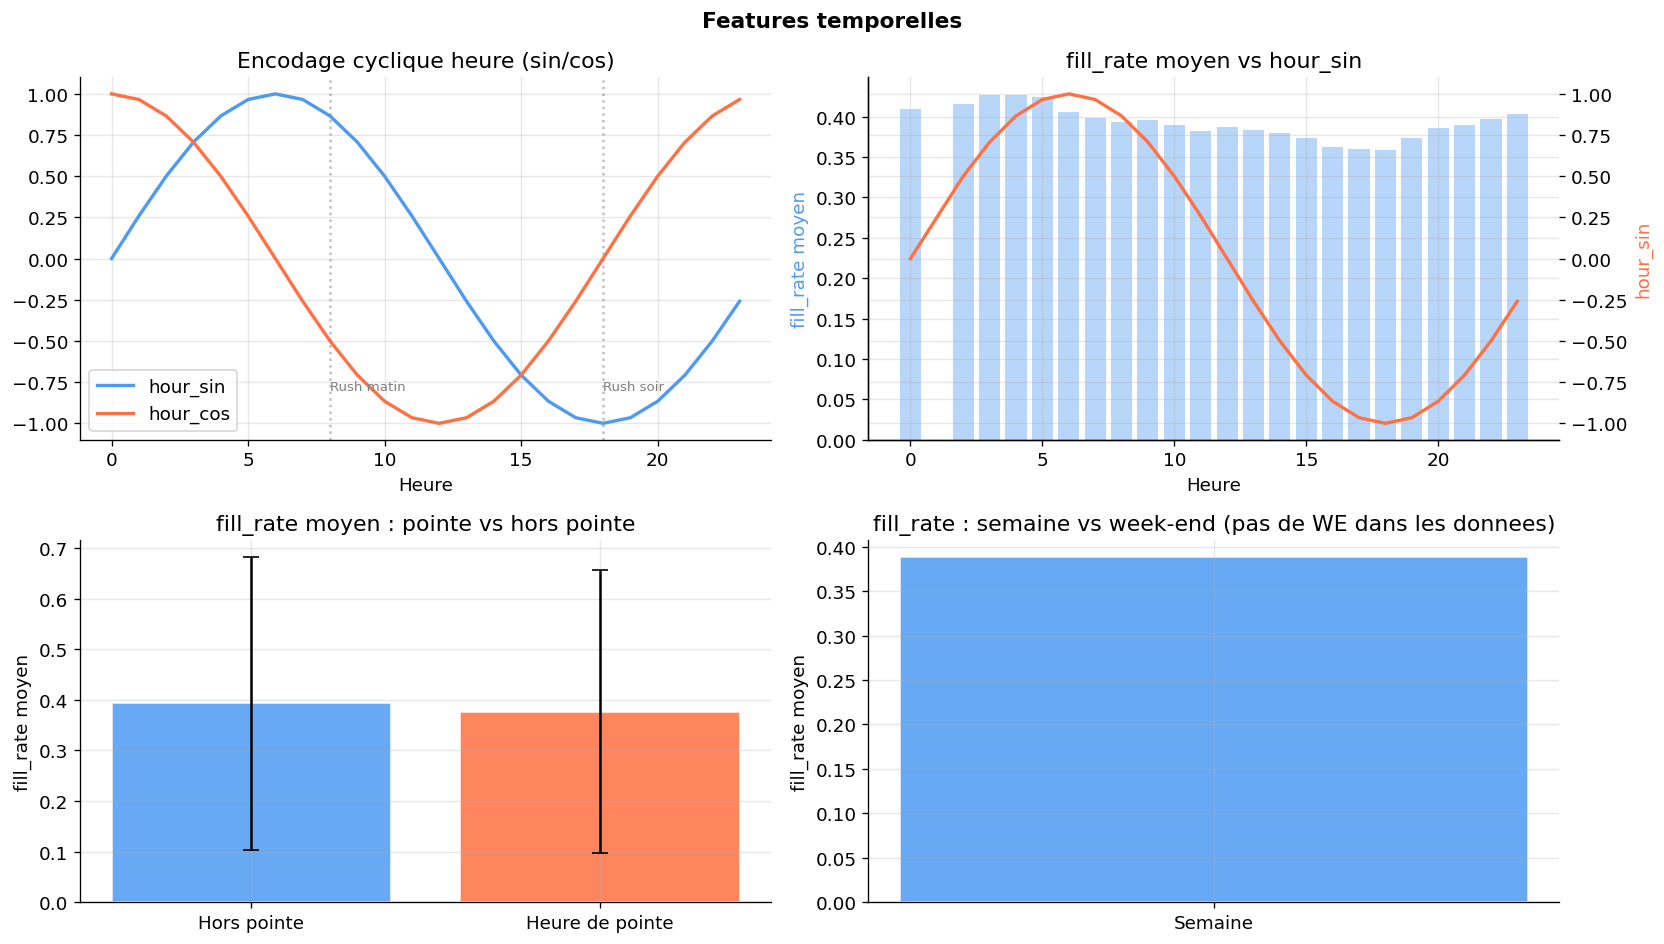

[OK] Figure sauvegardee


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Features temporelles', fontsize=13, fontweight='bold')

# Encodage cyclique heure
ax = axes[0, 0]
hours = np.arange(24)
ax.plot(hours, np.sin(2*np.pi*hours/24), label='hour_sin', color='#4E9AF1', linewidth=2)
ax.plot(hours, np.cos(2*np.pi*hours/24), label='hour_cos', color='#FF7043', linewidth=2)
ax.set_title('Encodage cyclique heure (sin/cos)')
ax.set_xlabel('Heure')
ax.legend()
ax.axvline(x=8,  color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=18, color='gray', linestyle=':', alpha=0.5)
ax.annotate('Rush matin', xy=(8,  -0.8), fontsize=8, color='gray')
ax.annotate('Rush soir',  xy=(18, -0.8), fontsize=8, color='gray')

# Correlation temporelle avec fill_rate
ax2 = axes[0, 1]
hourly_fr = df_features.groupby('hour')['fill_rate'].mean()
ax2_twin = ax2.twinx()
ax2.bar(hourly_fr.index, hourly_fr.values, alpha=0.4, color='#4E9AF1', label='fill_rate moy')
ax2_twin.plot(hourly_fr.index, np.sin(2*np.pi*hourly_fr.index/24),
              color='#FF7043', linewidth=2, label='hour_sin')
ax2.set_title('fill_rate moyen vs hour_sin')
ax2.set_xlabel('Heure')
ax2.set_ylabel('fill_rate moyen', color='#4E9AF1')
ax2_twin.set_ylabel('hour_sin', color='#FF7043')

# Rush vs hors pointe (si les deux existent)
ax3 = axes[1, 0]
rush_stats = df_features.groupby('is_rush')['fill_rate'].agg(['mean','std'])
rush_labels_map = {0: 'Hors pointe', 1: 'Heure de pointe'}
rush_labels = [rush_labels_map[i] for i in rush_stats.index]
rush_colors = ['#4E9AF1' if i == 0 else '#FF7043' for i in rush_stats.index]
x_rush = np.arange(len(rush_stats))
ax3.bar(x_rush, rush_stats['mean'], color=rush_colors, alpha=0.85, edgecolor='white')
if len(rush_stats) > 1:
    ax3.errorbar(x_rush, rush_stats['mean'], yerr=rush_stats['std'],
                 fmt='none', color='black', capsize=5)
ax3.set_xticks(x_rush)
ax3.set_xticklabels(rush_labels)
ax3.set_title('fill_rate moyen : pointe vs hors pointe')
ax3.set_ylabel('fill_rate moyen')

# Weekend vs semaine (si les deux existent)
ax4 = axes[1, 1]
we_stats = df_features.groupby('is_weekend')['fill_rate'].agg(['mean','std'])
we_labels_map = {0: 'Semaine', 1: 'Week-end'}
we_labels = [we_labels_map[i] for i in we_stats.index]
we_colors = ['#4E9AF1' if i == 0 else '#6BCB77' for i in we_stats.index]
x_we = np.arange(len(we_stats))
ax4.bar(x_we, we_stats['mean'], color=we_colors, alpha=0.85, edgecolor='white')
if len(we_stats) > 1:
    ax4.errorbar(x_we, we_stats['mean'], yerr=we_stats['std'],
                 fmt='none', color='black', capsize=5)
ax4.set_xticks(x_we)
ax4.set_xticklabels(we_labels)
n_we = (df_features['is_weekend'] == 1).sum()
title_we = f'fill_rate : semaine vs week-end'
if n_we == 0:
    title_we += ' (pas de WE dans les donnees)'
ax4.set_title(title_we)
ax4.set_ylabel('fill_rate moyen')

plt.tight_layout()
plt.savefig(str(FIG_DIR / '02_features_temporelles.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')

## 4. Features de voisinage -- stations proches

Une station qui se vide rapidement est souvent entouree de stations
qui se vident aussi (meme quartier, meme flux pendulaire).

On calcule le **fill_rate moyen des N stations les plus proches**
comme feature de contexte spatial.

**Algorithme :** cKDTree (k-d tree) sur les coordonnees lat/lon
pour trouver les k voisins les plus proches en O(log n).

In [12]:
# Construction du k-d tree sur les positions des stations
N_NEIGHBORS = 5  # nombre de voisins

# Positions uniques des stations
station_pos = (
    df_features
    .groupby('station_id')[['lat','lon']]
    .first()
    .dropna()
    .reset_index()
)

# Conversion deg -> radians pour distance approximative
coords_rad = np.radians(station_pos[['lat','lon']].values)
tree = cKDTree(coords_rad)

# Pour chaque station, trouver les N_NEIGHBORS plus proches
# (on exclut la station elle-meme -> k+1 voisins, on drop le 1er)
distances, indices = tree.query(coords_rad, k=N_NEIGHBORS + 1)

# Mapping station_id -> indices voisins
station_ids = station_pos['station_id'].values
neighbors_map = {}
for i, sid in enumerate(station_ids):
    neighbor_idx = indices[i, 1:]  # exclure soi-meme
    neighbor_ids = station_ids[neighbor_idx]
    dist_km = distances[i, 1:] * 6371  # approximation rayon terre
    neighbors_map[sid] = list(zip(neighbor_ids, dist_km))

print(f'[OK] k-d tree construit sur {len(station_pos)} stations')
print(f'N_NEIGHBORS = {N_NEIGHBORS}')

# Exemple
ex_sid = station_pos['station_id'].iloc[0]
print(f'\nVoisins de la station {ex_sid} :')
for nid, dist in neighbors_map[ex_sid]:
    print(f'  Station {nid} -- distance {dist*1000:.0f}m')

[OK] k-d tree construit sur 1485 stations
N_NEIGHBORS = 5

Voisins de la station 6245 :
  Station 27363256 -- distance 37m
  Station 27414527 -- distance 145m
  Station 2514995690 -- distance 260m
  Station 210389577 -- distance 330m
  Station 210328645 -- distance 349m


In [13]:
# Calcul du fill_rate moyen des voisins pour chaque (station, timestamp)
print('Calcul features voisinage...')

# Pivot : ts_utc x station_id -> fill_rate
fr_pivot = (
    df_features[['ts_utc','station_id','fill_rate']]
    .drop_duplicates(subset=['ts_utc','station_id'])
    .pivot(index='ts_utc', columns='station_id', values='fill_rate')
)

print(f'Pivot shape : {fr_pivot.shape}')

# Pour chaque station, calculer mean fill_rate des voisins
neighbor_fr_data = {}

for sid in station_ids:
    if sid not in fr_pivot.columns:
        continue
    neighbor_ids = [nid for nid, _ in neighbors_map.get(sid, []) if nid in fr_pivot.columns]
    if neighbor_ids:
        neighbor_fr_data[sid] = fr_pivot[neighbor_ids].mean(axis=1)

# Assembler en DataFrame
df_neighbor_fr = pd.DataFrame(neighbor_fr_data).reset_index()
df_neighbor_fr = df_neighbor_fr.melt(
    id_vars='ts_utc',
    var_name='station_id',
    value_name='neighbor_fr_mean'
)
df_neighbor_fr['ts_utc'] = pd.to_datetime(df_neighbor_fr['ts_utc'], utc=True)

print(f'[OK] Voisinage calcule : {df_neighbor_fr.shape}')
print(df_neighbor_fr['neighbor_fr_mean'].describe().round(3))

Calcul features voisinage...
Pivot shape : (147, 1485)
[OK] Voisinage calcule : (218295, 3)
count    218295.000
mean          0.386
std           0.215
min           0.000
25%           0.211
50%           0.359
75%           0.531
max           1.000
Name: neighbor_fr_mean, dtype: float64


## 5. Assemblage du dataset final

On fusionne :
- Features adstock (drainage)
- Features temporelles (sin/cos, indicateurs)
- Features de voisinage (fill_rate moyen des stations proches)
- Target : fill_rate(t+30min)

Ce dataset sera l'input direct du modele bayesien PyMC (notebook 03).

In [14]:
# Fusion avec le dataset target
df_model = df_target.merge(
    df_features[['station_id','ts_utc',
                 'hour','day_of_week','is_rush','is_weekend','is_night',
                 'hour_sin','hour_cos','dow_sin','dow_cos','time_of_day',
                 'drainage','adstock_drain','surplus',
                 'lat','lon','capacity','available_mechanical','available_ebike']],
    on=['station_id','ts_utc'],
    how='inner'
)

# Fusion voisinage
df_model = df_model.merge(
    df_neighbor_fr,
    on=['station_id','ts_utc'],
    how='left'
)

# Supprimer les lignes sans target
df_model = df_model.dropna(subset=['fill_rate_t30']).copy()

# Features finales
FEATURE_COLS = [
    'fill_rate',          # fill_rate actuel (autoregression)
    'adstock_drain',      # memoire du drainage (analogie adstock)
    'drainage',           # drainage instantane
    'surplus',            # arrivees de velos
    'hour_sin',           # heure (sin)
    'hour_cos',           # heure (cos)
    'dow_sin',            # jour semaine (sin)
    'dow_cos',            # jour semaine (cos)
    'is_rush',            # heure de pointe
    'is_weekend',         # week-end
    'is_night',           # nuit
    'neighbor_fr_mean',   # fill_rate moyen voisins
]

TARGET_COL = 'fill_rate_t30'

# Nettoyer les NaN restants sur les features
df_model[FEATURE_COLS] = df_model[FEATURE_COLS].fillna(df_model[FEATURE_COLS].median())

print(f'[OK] Dataset final : {df_model.shape}')
print(f'Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}')
print(f'Target   : {TARGET_COL}')
print(f'Nulls restants : {df_model[FEATURE_COLS + [TARGET_COL]].isna().sum().sum()}')
df_model[FEATURE_COLS + [TARGET_COL]].describe().round(3)

[OK] Dataset final : (167693, 23)
Features (12) : ['fill_rate', 'adstock_drain', 'drainage', 'surplus', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_rush', 'is_weekend', 'is_night', 'neighbor_fr_mean']
Target   : fill_rate_t30
Nulls restants : 0


,fill_rate,adstock_drain,drainage,surplus,hour_sin,hour_cos,dow_sin,dow_cos,is_rush,is_weekend,is_night,neighbor_fr_mean,fill_rate_t30
count,167693.000,167693.000,167693.000,167693.000,167693.000,167693.000,167693.000,167693.000,167693.000,167693.0,167693.000,167693.000,167693.000
mean,0.387,0.027,0.017,0.016,-0.228,-0.199,0.483,0.691,0.327,0.0,0.159,0.385,0.387
std,0.285,0.044,0.039,0.037,0.735,0.607,0.392,0.369,0.469,0.0,0.366,0.216,0.284
min,0.000,0.000,0.000,0.000,-1.000,-1.000,0.000,-0.901,0.000,0.0,0.000,0.000,0.000
25%,0.143,0.001,0.000,0.000,-0.866,-0.707,0.000,0.623,0.000,0.0,0.000,0.209,0.143
50%,0.321,0.010,0.000,0.000,-0.500,-0.259,0.782,0.623,0.000,0.0,0.000,0.357,0.321
75%,0.600,0.037,0.020,0.019,0.500,0.259,0.782,1.000,1.000,0.0,0.000,0.531,0.600
max,1.000,0.873,0.852,0.889,1.000,0.966,0.975,1.000,1.000,0.0,1.000,1.000,1.000


## 6. Correlations et validation des features

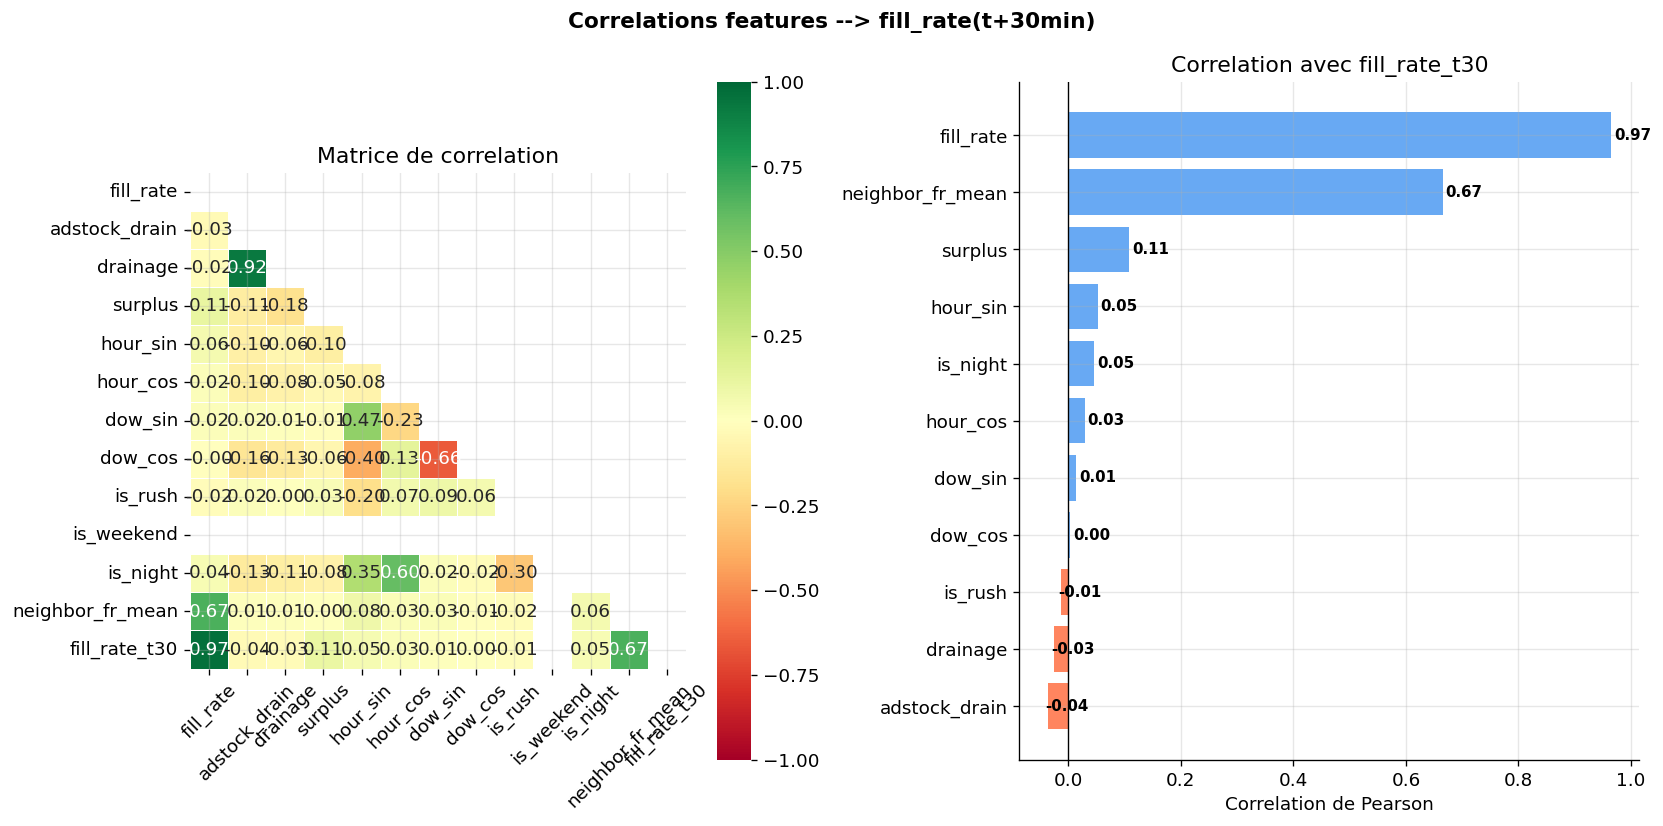

=== Correlations avec fill_rate(t+30min) ===
  fill_rate                 r=+0.965  [fort]
  neighbor_fr_mean          r=+0.665  [fort]
  surplus                   r=+0.108  [modere]
  hour_sin                  r=+0.052  [faible]
  is_night                  r=+0.046  [faible]
  hour_cos                  r=+0.029  [faible]
  dow_sin                   r=+0.014  [faible]
  dow_cos                   r=+0.003  [faible]
  is_rush                   r=-0.013  [faible]
  drainage                  r=-0.026  [faible]
  adstock_drain             r=-0.037  [faible]
  is_weekend                r=+nan  [faible]


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Correlations features --> fill_rate(t+30min)', fontsize=13, fontweight='bold')

# Matrice de correlation
ax = axes[0]
corr_cols = FEATURE_COLS + [TARGET_COL]
corr = df_model[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3,
            xticklabels=corr.columns,
            yticklabels=corr.columns)
ax.set_title('Matrice de correlation')
ax.tick_params(axis='x', rotation=45)

# Correlation avec la target
ax2 = axes[1]
corr_target = corr[TARGET_COL].drop(TARGET_COL).sort_values(ascending=True)
colors_bar = ['#FF7043' if v < 0 else '#4E9AF1' for v in corr_target.values]
bars = ax2.barh(corr_target.index, corr_target.values, color=colors_bar, alpha=0.85)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_title(f'Correlation avec {TARGET_COL}')
ax2.set_xlabel('Correlation de Pearson')
for bar, val in zip(bars, corr_target.values):
    ax2.text(val + 0.005 * np.sign(val), bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(str(FIG_DIR / '02_correlations_features.png'), bbox_inches='tight', dpi=150)
plt.show()

print('=== Correlations avec fill_rate(t+30min) ===')
for feat, val in corr_target.sort_values(ascending=False).items():
    tag = '[fort]' if abs(val) > 0.3 else '[modere]' if abs(val) > 0.1 else '[faible]'
    print(f'  {feat:<25} r={val:+.3f}  {tag}')

## 7. Export du dataset final

In [16]:
out_path = PROC_DIR / 'velib_features.parquet'
df_model.to_parquet(out_path, index=False)

# Sauvegarder la config des features pour le notebook 03
import json
config = {
    'feature_cols':   FEATURE_COLS,
    'target_col':     TARGET_COL,
    'alpha_adstock':  ALPHA_ADSTOCK,
    'n_neighbors':    N_NEIGHBORS,
    'horizon_min':    HORIZON_MIN,
    'n_stations':     int(df_model['station_id'].nunique()),
    'n_obs':          len(df_model),
}
(PROC_DIR / 'features_config.json').write_text(json.dumps(config, indent=2))

print(f'[OK] Dataset features : {out_path}')
print(f'     {df_model.shape[0]:,} lignes x {df_model.shape[1]} colonnes')
print(f'[OK] Config sauvegardee : {PROC_DIR / "features_config.json"}')

[OK] Dataset features : /Users/souhail/projets-ml/Velib-analytics/data/processed/velib_features.parquet
     167,693 lignes x 23 colonnes
[OK] Config sauvegardee : /Users/souhail/projets-ml/Velib-analytics/data/processed/features_config.json


## 8. Synthese

In [17]:
print('=' * 65)
print('  SYNTHESE FEATURE ENGINEERING -- VelibMMM')
print('=' * 65)

corr_t = df_model[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)

print()
print('TARGET')
print(f'  fill_rate(t+30min) : mean={df_model[TARGET_COL].mean():.3f}  std={df_model[TARGET_COL].std():.3f}')
print()
print('ADSTOCK DRAINAGE (analogie adstock TV)')
print(f'  alpha = {ALPHA_ADSTOCK}  |  demi-vie = {hl:.1f} snapshots')
print(f'  drainage mean    : {df_model["drainage"].mean():.4f}')
print(f'  adstock_drain mean: {df_model["adstock_drain"].mean():.4f}')
print()
print('CORRELATIONS AVEC TARGET (fill_rate t+30)')
for f, v in corr_t.sort_values(ascending=False).items():
    tag = '[fort]' if abs(v) > 0.3 else '[modere]' if abs(v) > 0.1 else '[faible]'
    print(f'  {f:<25} r={v:+.3f}  {tag}')
print()
print(f'DATASET FINAL')
print(f'  Shape    : {df_model.shape}')
print(f'  Features : {len(FEATURE_COLS)}')
print()
print('PROCHAINE ETAPE --> Notebook 03 : Modele bayesien (PyMC)')
print('  - Beta regression : fill_rate ~ Beta(mu, kappa)')
print('  - mu = sigmoid(alpha + sum(beta_k * X_k))')
print('  - MCMC NUTS : distribution posterieure des coefficients')
print('  - Chaines de Markov -> distribution stationnaire = posterieure')
print('=' * 65)

  SYNTHESE FEATURE ENGINEERING -- VelibMMM

TARGET
  fill_rate(t+30min) : mean=0.387  std=0.284

ADSTOCK DRAINAGE (analogie adstock TV)
  alpha = 0.4  |  demi-vie = 0.8 snapshots
  drainage mean    : 0.0166
  adstock_drain mean: 0.0273

CORRELATIONS AVEC TARGET (fill_rate t+30)
  fill_rate                 r=+0.965  [fort]
  neighbor_fr_mean          r=+0.665  [fort]
  surplus                   r=+0.108  [modere]
  hour_sin                  r=+0.052  [faible]
  is_night                  r=+0.046  [faible]
  hour_cos                  r=+0.029  [faible]
  dow_sin                   r=+0.014  [faible]
  dow_cos                   r=+0.003  [faible]
  is_rush                   r=-0.013  [faible]
  drainage                  r=-0.026  [faible]
  adstock_drain             r=-0.037  [faible]
  is_weekend                r=+nan  [faible]

DATASET FINAL
  Shape    : (167693, 23)
  Features : 12

PROCHAINE ETAPE --> Notebook 03 : Modele bayesien (PyMC)
  - Beta regression : fill_rate ~ Beta(mu, kappa